In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv']

In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Welcome.pdf', 'IMG_0243.HEIC', 'Screenshot 2025-07-15 185158.pdf', 'Scanned 15 Jul 2025 at 6:56:23\u202fPM (1).pdf', 'Scanned 15 Jul 2025 at 6:56:23\u202fPM.pdf', 'Scanned 15 Jul 2025 at 6:59:01\u202fPM.pdf', 'DEDF6A3C-0B57-4D3B-8527-A62FCCF4C131 (1).jpeg', 'Worksheet 1.gdoc', 'english worksheet;-2', 'Copy of Worksheet - 2.gdoc', 'english worksheet 3.gdoc', ' english worksheet 3.gdoc', 'enlish worksheet-3', 'english workksheet-1', 'Copy of Worksheet 5.docx', 'Copy of Worksheet 5 (1).gdoc', 'Copy of Worksheet 5.gdoc', 'Copy of Worksheet 6.docx', 'Copy of Worksheet 6.gdoc', 'Session 7 Vocabulary (Synonyms and Antonyms) - Worksheet.gdoc', 'Copy of Session 7 worksheet.docx', 'CO1 ALM2.pdf', 'Saved from the Google app', 'Session_01_Introduction (1).pdf', 'Session_01_Introduction.pdf', 'Pikley_Pom_Baby_John_Varun_Dhawan,_Wamiqa_Vishal_Mishra,_Riya_Seepana,_Thaman_S,_Irshad_Kamil_[_YouCon.mp3', '2520030360_sec-4_video resume.mp4', 'cfai', 'code tantra.pdf', 'sports fee (1

FULL LOGISTIC REGRESSION PIPELINE PROJECT

Dataset loaded successfully!

Dataset Shape:
(1143, 13)

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   

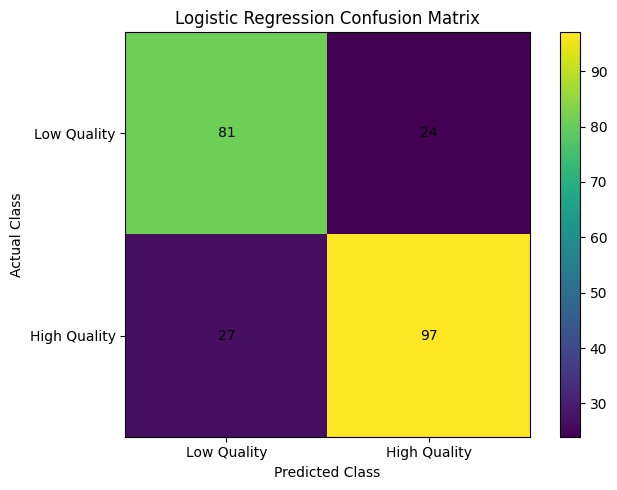

<Figure size 700x500 with 0 Axes>

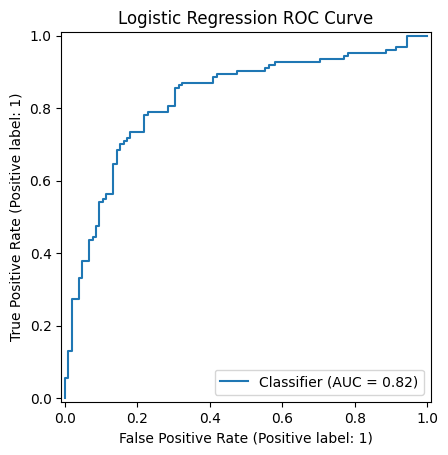


FEATURE COEFFICIENTS
             Feature  Coefficient
             alcohol     1.028629
           sulphates     0.476369
 free sulfur dioxide     0.231491
       fixed acidity     0.200850
             density     0.057608
                  pH     0.026769
                  Id    -0.008073
      residual sugar    -0.034734
           chlorides    -0.107916
         citric acid    -0.289433
total sulfur dioxide    -0.548549
    volatile acidity    -0.609358


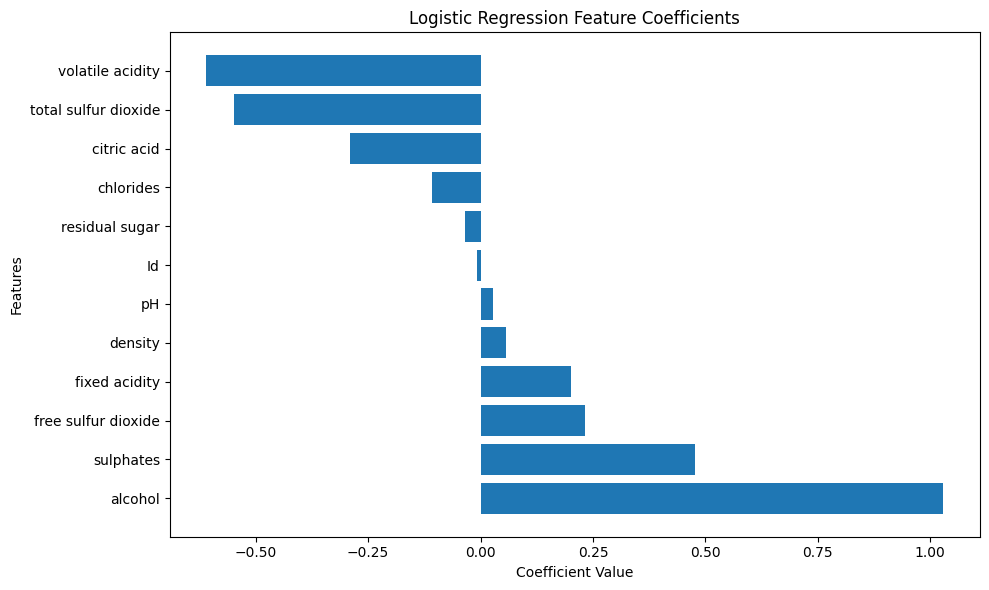


Results saved successfully!

Saved Files:
1. full_logistic_regression_pipeline_results.csv
2. logistic_regression_feature_coefficients.csv

FINAL CONCLUSION


The WineQT dataset was used to build a complete
Binary Logistic Regression Pipeline.

Wine quality was converted into two categories:

0 = Low Quality Wine  (quality <= 5)
1 = High Quality Wine (quality >= 6)

The pipeline automatically performed:

1. Missing Value Imputation
2. Feature Scaling
3. Logistic Regression Classification

The model was evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. ROC-AUC
6. Confusion Matrix
7. ROC Curve

FINAL RESULTS

Accuracy : 0.7773
Precision: 0.8017
Recall   : 0.7823
F1 Score : 0.7918
ROC-AUC  : 0.8240




In [5]:
# ============================================================
# FULL LOGISTIC REGRESSION PIPELINE PROJECT
# Dataset: WineQT.csv
# Binary Classification:
# 0 = Low Quality Wine  (quality <= 5)
# 1 = High Quality Wine (quality >= 6)
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

# Google Drive dataset path
DATA_PATH = "/content/drive/MyDrive/Colab/WineQT.csv"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("FULL LOGISTIC REGRESSION PIPELINE PROJECT")
print("=" * 60)

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 5. REMOVE DUPLICATES
# ------------------------------------------------------------

duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicates)

if duplicates > 0:

    df = df.drop_duplicates()

    print("Duplicate rows removed!")

else:

    print("No duplicate rows found!")


# ------------------------------------------------------------
# 6. CREATE BINARY TARGET VARIABLE
# ------------------------------------------------------------

# Original target = quality
# 0 -> Low Quality  (quality <= 5)
# 1 -> High Quality (quality >= 6)

df["QualityCategory"] = np.where(
    df["quality"] >= 6,
    1,
    0
)


print("\n" + "=" * 60)
print("BINARY TARGET DISTRIBUTION")
print("=" * 60)

print(
    df["QualityCategory"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 7. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

# Drop original quality because it was used
# to create QualityCategory.
# This prevents data leakage.

X = df.drop(
    columns=[
        "quality",
        "QualityCategory"
    ]
)

y = df["QualityCategory"]


print("\nFeature Shape:", X.shape)

print("Target Shape:", y.shape)


# ------------------------------------------------------------
# 8. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=RANDOM_STATE

)


print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 9. CREATE LOGISTIC REGRESSION PIPELINE
# ------------------------------------------------------------

pipeline = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            StandardScaler()
        ),

        (
            "logistic_regression",

            LogisticRegression(

                max_iter=5000,

                random_state=RANDOM_STATE

            )
        )

    ]

)


print("\nPipeline Created Successfully!")

print(
    "\nPipeline Steps:"
)

print(pipeline)


# ------------------------------------------------------------
# 10. TRAIN THE PIPELINE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION PIPELINE")
print("=" * 60)


pipeline.fit(

    X_train,

    y_train

)


print(
    "Pipeline trained successfully!"
)


# ------------------------------------------------------------
# 11. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = pipeline.predict(
    X_test
)


y_prob = pipeline.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------------------
# 12. MODEL EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)


print(
    "Accuracy :",
    round(accuracy, 4)
)


print(
    "Precision:",
    round(precision, 4)
)


print(
    "Recall   :",
    round(recall, 4)
)


print(
    "F1 Score :",
    round(f1, 4)
)


print(
    "ROC-AUC  :",
    round(roc_auc, 4)
)


# ------------------------------------------------------------
# 13. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)


print(

    classification_report(

        y_test,

        y_pred,

        target_names=[
            "Low Quality",
            "High Quality"
        ],

        zero_division=0

    )

)


# ------------------------------------------------------------
# 14. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test,

    y_pred

)


print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)


print(cm)


# ------------------------------------------------------------
# 15. VISUALIZE CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)


plt.imshow(
    cm
)


plt.colorbar()


classes = [
    "Low Quality",
    "High Quality"
]


plt.xticks(
    range(len(classes)),
    classes
)


plt.yticks(
    range(len(classes)),
    classes
)


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "Actual Class"
)


plt.title(
    "Logistic Regression Confusion Matrix"
)


for i in range(
    len(cm)
):

    for j in range(
        len(cm[0])
    ):

        plt.text(

            j,

            i,

            str(cm[i, j]),

            ha="center",

            va="center"

        )


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 16. ROC CURVE
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)


RocCurveDisplay.from_predictions(

    y_test,

    y_prob

)


plt.title(
    "Logistic Regression ROC Curve"
)


plt.show()


# ------------------------------------------------------------
# 17. FEATURE COEFFICIENTS
# ------------------------------------------------------------

logistic_model = pipeline.named_steps[
    "logistic_regression"
]


coefficients_df = pd.DataFrame({

    "Feature":
    X.columns,

    "Coefficient":
    logistic_model.coef_[0]

})


coefficients_df = coefficients_df.sort_values(

    by="Coefficient",

    ascending=False

)


print("\n" + "=" * 60)
print("FEATURE COEFFICIENTS")
print("=" * 60)

print(
    coefficients_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 18. FEATURE COEFFICIENT VISUALIZATION
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.barh(

    coefficients_df["Feature"],

    coefficients_df["Coefficient"]

)


plt.xlabel(
    "Coefficient Value"
)


plt.ylabel(
    "Features"
)


plt.title(
    "Logistic Regression Feature Coefficients"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 19. SAVE RESULTS
# ------------------------------------------------------------

results_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"

    ],

    "Score": [

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

})


results_df.to_csv(

    "full_logistic_regression_pipeline_results.csv",

    index=False

)


coefficients_df.to_csv(

    "logistic_regression_feature_coefficients.csv",

    index=False

)


print("\nResults saved successfully!")

print(
    "\nSaved Files:"
)

print(
    "1. full_logistic_regression_pipeline_results.csv"
)

print(
    "2. logistic_regression_feature_coefficients.csv"
)


# ------------------------------------------------------------
# 20. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)


print(f"""

The WineQT dataset was used to build a complete
Binary Logistic Regression Pipeline.

Wine quality was converted into two categories:

0 = Low Quality Wine  (quality <= 5)
1 = High Quality Wine (quality >= 6)

The pipeline automatically performed:

1. Missing Value Imputation
2. Feature Scaling
3. Logistic Regression Classification

The model was evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. ROC-AUC
6. Confusion Matrix
7. ROC Curve

FINAL RESULTS

Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1 Score : {f1:.4f}
ROC-AUC  : {roc_auc:.4f}

""")

print("=" * 60)